<a href="https://colab.research.google.com/github/Paulohenrique3897/algoritmos-python/blob/main/algoritmo_caminho_networkx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NOME: PAULO HENRIQUE SCVARIELLO GUIMARAES
RA:25017738

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import math

matriz = [
    [2,3,1,3,1,2],
    [3,3,2,1,2,3],
    [1,2,3,2,3,1],
    [3,1,2,2,3,3],
    [1,2,3,2,3,1],
    [2,3,1,1,2,3]
]

linhas = len(matriz)
colunas = len(matriz[0])

G = nx.DiGraph()
pos = {}

circulos = []
quadrados = []
triangulos = []



In [ ]:
for i in range(linhas):
    for j in range(colunas):
        no = (i, j)
        forma = matriz[i][j]
        G.add_node(no, forma=forma)
        pos[no] = (j, -i)

        if forma == 1: circulos.append(no)
        elif forma == 2: quadrados.append(no)
        elif forma == 3: triangulos.append(no)

In [ ]:
def dist(n1, n2):
    return math.sqrt((n1[0]-n2[0])**2 + (n1[1]-n2[1])**2)

for no in G.nodes():
    forma = G.nodes[no]['forma']
    i, j = no
    destinos_validos = []

    if forma == 1:
        destinos_validos = quadrados

    elif forma == 2:
        destinos_validos = [t for t in triangulos if (t[0] >= i and t[1] >= j) and t != no]

    elif forma == 3:
        destinos_validos = [q for q in quadrados if abs(q[0]-i) == abs(q[1]-j) and q != no]

    if destinos_validos:
        menor_dist = min(dist(no, dest) for dest in destinos_validos)
        melhores_destinos = [dest for dest in destinos_validos if dist(no, dest) == menor_dist]
        G.add_edge(no, melhores_destinos[0])

nos_finais = [no for no, out_degree in G.out_degree() if out_degree == 0]

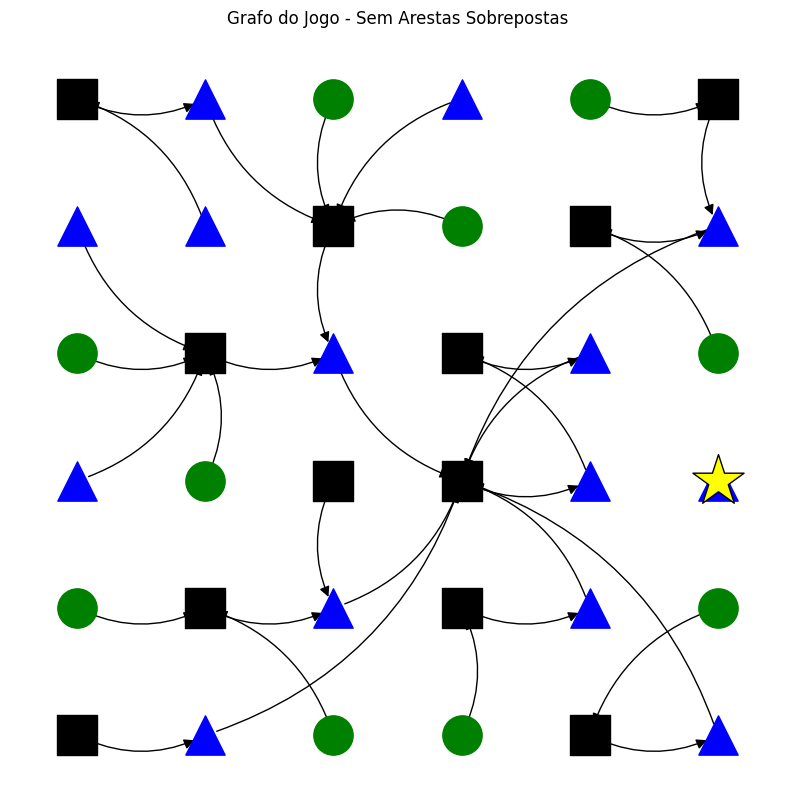

In [ ]:
plt.figure(figsize=(10, 10))

nx.draw_networkx_nodes(G, pos, nodelist=circulos, node_shape='o', node_color='green', node_size=800)
nx.draw_networkx_nodes(G, pos, nodelist=quadrados, node_shape='s', node_color='black', node_size=800)
nx.draw_networkx_nodes(G, pos, nodelist=triangulos, node_shape='^', node_color='blue', node_size=800)

if nos_finais:
    nx.draw_networkx_nodes(G, pos, nodelist=nos_finais, node_shape='*', node_color='yellow', node_size=1500, edgecolors='black')

nx.draw_networkx_edges(G, pos, edge_color='black', arrows=True, arrowsize=15, connectionstyle='arc3,rad=0.25')

plt.axis('off')
plt.title("Grafo do Jogo - Sem Arestas Sobrepostas")
plt.show()